# Owen — SPE DSEATS Africa Datathon 2026

## 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

# just so plots don't look terrible out of the box
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

train = pd.read_csv('../data/oil_presence_trainset.csv')
test  = pd.read_csv('../data/oil_presence_testset.csv')

print("train:", train.shape, "  test:", test.shape)

train: (3000, 8)   test: (2000, 7)


## 2. Exploratory Data Analysis
### 2.1 Structural Overview

In [2]:
# quick look at both sets
print("=== TRAIN ===")
print(train.info())
print()
train.head(3)

=== TRAIN ===
<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Rock_Type                  3000 non-null   str    
 1   Porosity                   2197 non-null   float64
 2   Permeability               1814 non-null   float64
 3   Trap_Type                  2233 non-null   str    
 4   Seismic_Score              1950 non-null   float64
 5   Proximity_to_Oil_Field     2057 non-null   float64
 6   Estimated_Reservoir_Depth  1732 non-null   float64
 7   Oil_Presence               3000 non-null   int64  
dtypes: float64(5), int64(1), str(2)
memory usage: 187.6 KB
None



,Rock_Type,Porosity,Permeability,Trap_Type,Seismic_Score,Proximity_to_Oil_Field,Estimated_Reservoir_Depth,Oil_Presence
0,Limestone,17.667992,834.277472,NaN,0.705933,2.431355,2228.0,1
1,Limestone,27.665758,578.158034,NaN,0.545806,2.606158,1610.0,0
2,Sandstone,28.855946,404.790685,NaN,0.167530,1.143136,2344.0,0


In [3]:
print("=== TEST ===")
print(test.info())
print()
test.head(3)

=== TEST ===
<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 7 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Rock_Type                  2000 non-null   str    
 1   Porosity                   2000 non-null   float64
 2   Permeability               2000 non-null   float64
 3   Trap_Type                  1514 non-null   str    
 4   Seismic_Score              2000 non-null   float64
 5   Proximity_to_Oil_Field     2000 non-null   float64
 6   Estimated_Reservoir_Depth  2000 non-null   int64  
dtypes: float64(4), int64(1), str(2)
memory usage: 109.5 KB
None



,Rock_Type,Porosity,Permeability,Trap_Type,Seismic_Score,Proximity_to_Oil_Field,Estimated_Reservoir_Depth
0,Limestone,21.897706,12.892564,Dome,0.035984,4.598459,1042
1,Sandstone,4.707518,196.078060,Anticline,0.421465,2.890416,3440
2,Sandstone,29.180662,573.420650,NaN,0.719487,1.361029,2544


In [4]:
# confirm the documented 3000/2000 split and that Oil_Presence is gone from test
print(f"Train rows: {len(train)}  |  Test rows: {len(test)}")
print(f"\nColumns in train not in test: {set(train.columns) - set(test.columns)}")
print("^ that's the target — good, test is blind")

# also flag the 6 duplicate rows found earlier
dups = train.duplicated().sum()
print(f"\nDuplicate rows in train: {dups}")

Train rows: 3000  |  Test rows: 2000

Columns in train not in test: {'Oil_Presence'}
^ that's the target — good, test is blind

Duplicate rows in train: 6


### 2.2 Missingness Analysis

Train has heavy missingness across all numeric features (27–43% per column). Test is nearly complete — only Trap_Type is missing there (~24%). This asymmetry matters: we can't just drop rows, and we have to fit any imputer on train then apply it to test. The two datasets are missing in completely different patterns.

In [5]:
# side by side missing % for train and test
miss = pd.DataFrame({
    'train_missing_n'   : train.isnull().sum(),
    'train_missing_pct' : (train.isnull().mean()*100).round(1),
    'test_missing_n'    : test.isnull().sum(),
    'test_missing_pct'  : (test.isnull().mean()*100).round(1),
})
miss[miss[['train_missing_n','test_missing_n']].sum(axis=1) > 0]

,train_missing_n,train_missing_pct,test_missing_n,test_missing_pct
Estimated_Reservoir_Depth,1268,42.3,0.0,0.0
Permeability,1186,39.5,0.0,0.0
Porosity,803,26.8,0.0,0.0
Proximity_to_Oil_Field,943,31.4,0.0,0.0
Seismic_Score,1050,35.0,0.0,0.0
Trap_Type,767,25.6,486.0,24.3


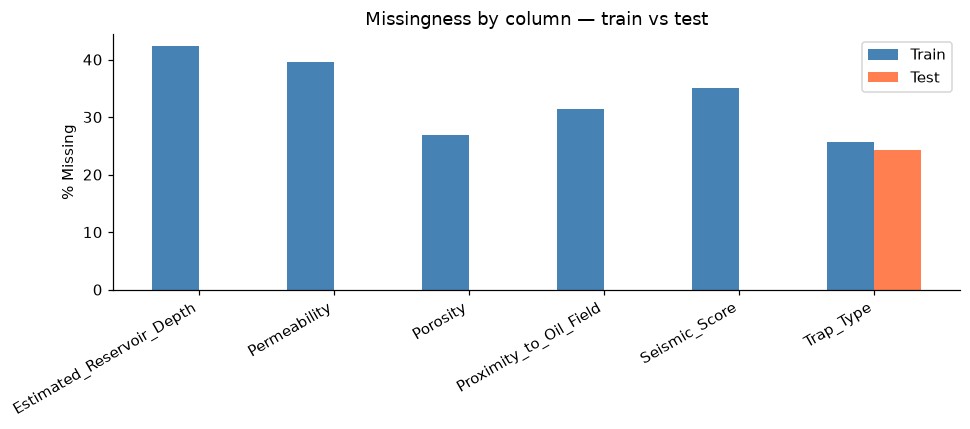

In [6]:
fig, ax = plt.subplots(figsize=(9, 4))

cols_with_missing = miss[miss[['train_missing_n','test_missing_n']].sum(axis=1) > 0].index.tolist()

x = np.arange(len(cols_with_missing))
w = 0.35

ax.bar(x - w/2, miss.loc[cols_with_missing, 'train_missing_pct'], width=w, label='Train', color='steelblue')
ax.bar(x + w/2, miss.loc[cols_with_missing, 'test_missing_pct'],  width=w, label='Test',  color='coral')

ax.set_xticks(x)
ax.set_xticklabels(cols_with_missing, rotation=30, ha='right')
ax.set_ylabel('% Missing')
ax.set_title('Missingness by column — train vs test')
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/images/missingness_bar.png', dpi=150, bbox_inches='tight')
plt.show()

### 2.3 Univariate Distributions

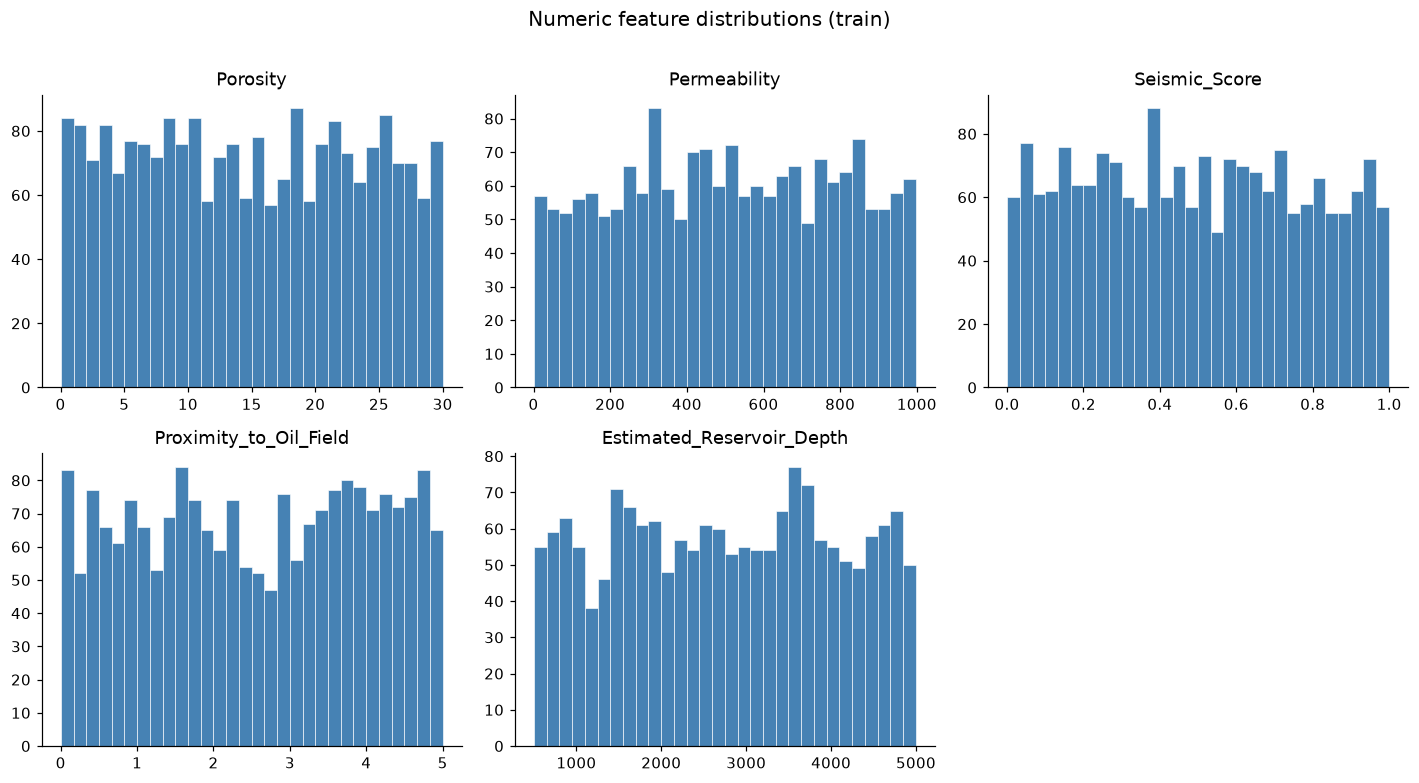

In [7]:
num_cols = ['Porosity', 'Permeability', 'Seismic_Score',
            'Proximity_to_Oil_Field', 'Estimated_Reservoir_Depth']

fig, axes = plt.subplots(2, 3, figsize=(13, 7))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(train[col].dropna(), bins=30, color='steelblue', edgecolor='white', linewidth=0.4)
    axes[i].set_title(col)
    axes[i].set_xlabel('')

# hide the 6th subplot (we only have 5 cols)
axes[5].set_visible(False)

fig.suptitle('Numeric feature distributions (train)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('../outputs/images/univariate_histograms.png', dpi=150, bbox_inches='tight')
plt.show()

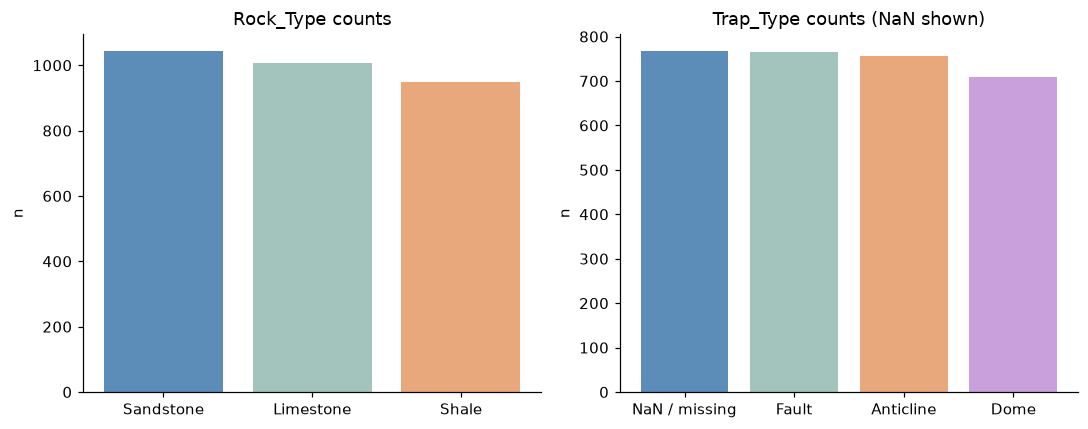

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

# Rock_Type
rock_counts = train['Rock_Type'].value_counts()
ax1.bar(rock_counts.index, rock_counts.values, color=['#5B8DB8','#A3C4BC','#E8A87C'])
ax1.set_title('Rock_Type counts')
ax1.set_ylabel('n')

# Trap_Type (include NaN explicitly)
trap_counts = train['Trap_Type'].value_counts(dropna=False)
trap_labels = [str(x) if str(x) != 'nan' else 'NaN / missing' for x in trap_counts.index]
ax2.bar(trap_labels, trap_counts.values, color=['#5B8DB8','#A3C4BC','#E8A87C','#C9A0DC'])
ax2.set_title('Trap_Type counts (NaN shown)')
ax2.set_ylabel('n')

plt.tight_layout()
plt.savefig('../outputs/images/categorical_counts.png', dpi=150, bbox_inches='tight')
plt.show()

### 2.4 Target Balance

Oil_Presence is imbalanced — roughly 72/28 (no oil vs oil). This means raw accuracy will be a misleading metric later; a model that predicts 0 every time would score ~72% without learning anything. We'll need to look at precision/recall or F1, and possibly use class_weight='balanced' in any classifier.

No oil (0): 2167  (72.2%)
Oil found (1): 833  (27.8%)


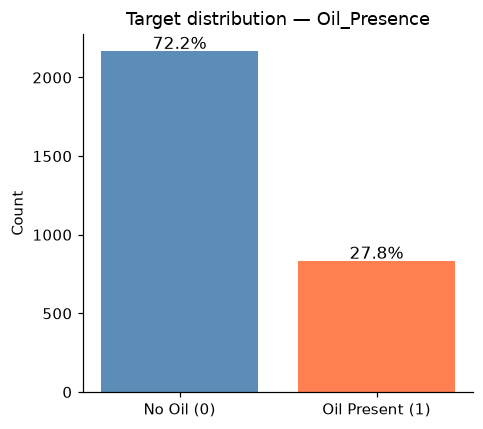

In [9]:
vc = train['Oil_Presence'].value_counts()
pct = (vc / len(train) * 100).round(1)

print(f"No oil (0): {vc[0]}  ({pct[0]}%)")
print(f"Oil found (1): {vc[1]}  ({pct[1]}%)")

fig, ax = plt.subplots(figsize=(4.5, 4))
ax.bar(['No Oil (0)', 'Oil Present (1)'], vc.values, color=['#5B8DB8','coral'])
for i, (v, p) in enumerate(zip(vc.values, pct.values)):
    ax.text(i, v + 15, f'{p}%', ha='center', fontsize=11)
ax.set_ylabel('Count')
ax.set_title('Target distribution — Oil_Presence')
plt.tight_layout()
plt.savefig('../outputs/images/target_balance.png', dpi=150, bbox_inches='tight')
plt.show()

### 2.5 Bivariate Analysis — features vs Oil_Presence

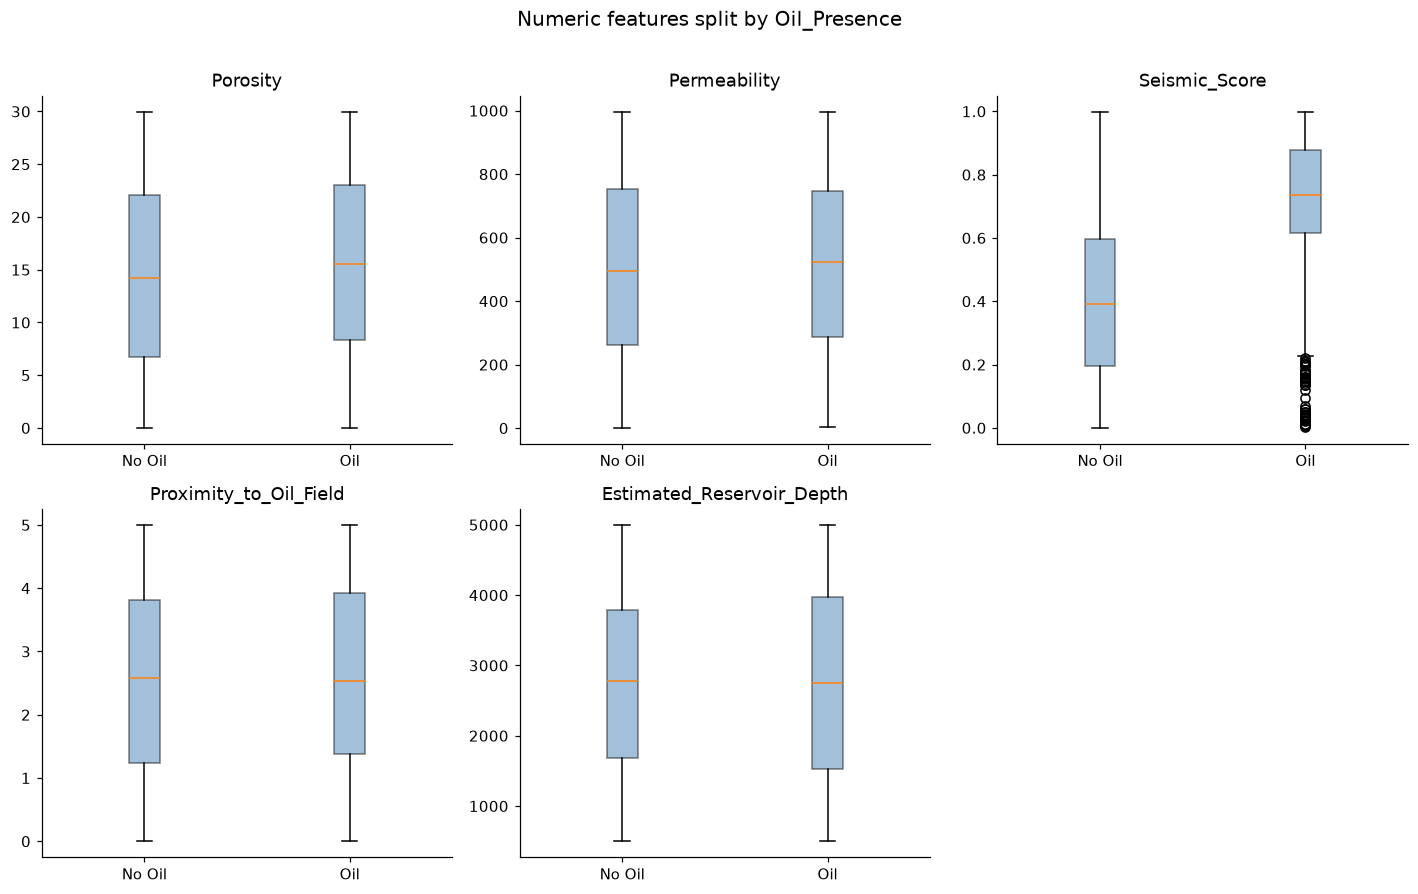

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(13, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    groups = [train.loc[train['Oil_Presence']==0, col].dropna(),
              train.loc[train['Oil_Presence']==1, col].dropna()]
    axes[i].boxplot(groups, tick_labels=['No Oil', 'Oil'], patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.5))
    axes[i].set_title(col)

axes[5].set_visible(False)
fig.suptitle('Numeric features split by Oil_Presence', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('../outputs/images/bivariate_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
means = train.groupby('Oil_Presence')[num_cols].mean().round(3)
means.index = ['No Oil (0)', 'Oil Present (1)']
means

,Porosity,Permeability,Seismic_Score,Proximity_to_Oil_Field,Estimated_Reservoir_Depth
No Oil (0),14.524,502.519,0.419,2.533,2759.656
Oil Present (1),15.405,513.499,0.691,2.580,2777.273


Seismic_Score separates the classes most clearly — mean of ~0.42 for no-oil rows vs ~0.69 when oil is found. Rock_Type also matters a lot (see 2.6 below). Porosity, Permeability, Proximity, and Depth show very weak separation on their own.

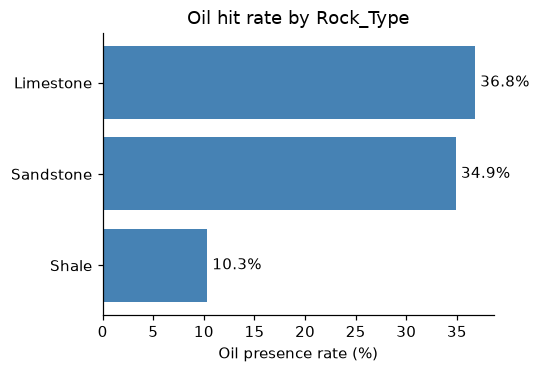

In [12]:
rock_oil_rate = train.groupby('Rock_Type')['Oil_Presence'].mean().sort_values()

fig, ax = plt.subplots(figsize=(5, 3.5))
ax.barh(rock_oil_rate.index, rock_oil_rate.values * 100, color='steelblue')
ax.set_xlabel('Oil presence rate (%)')
ax.set_title('Oil hit rate by Rock_Type')
for i, v in enumerate(rock_oil_rate.values):
    ax.text(v*100 + 0.5, i, f'{v*100:.1f}%', va='center')
plt.tight_layout()
plt.savefig('../outputs/images/rock_type_oil_rate.png', dpi=150, bbox_inches='tight')
plt.show()

### 2.6 Domain-Relevant Findings

This is the most important EDA section — it directly informs Part 2 corrections.

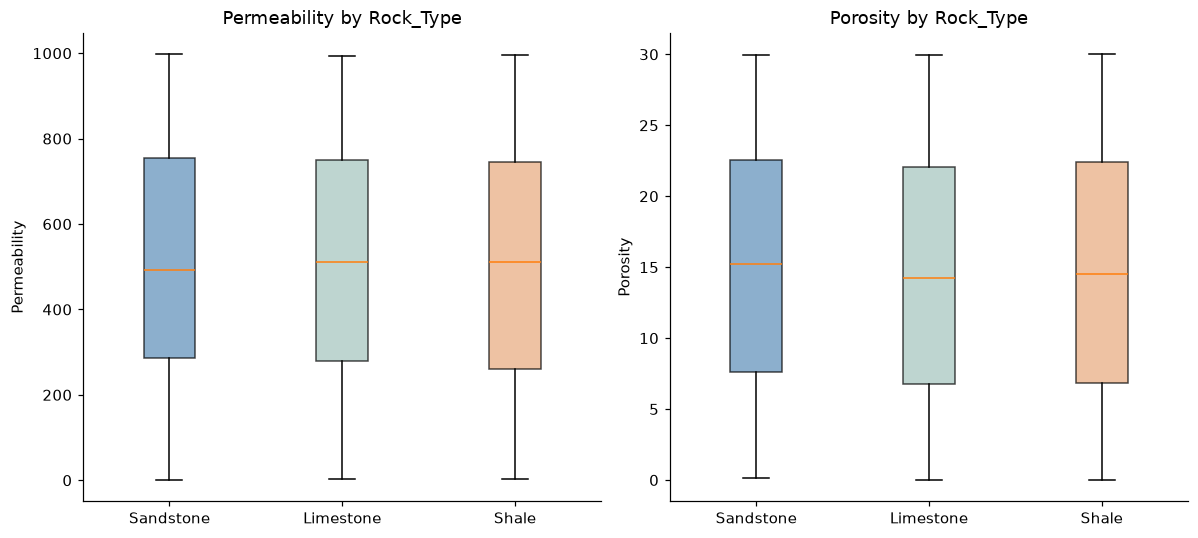

In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 5))

rock_types = ['Sandstone', 'Limestone', 'Shale']
colors = ['#5B8DB8', '#A3C4BC', '#E8A87C']

for ax, col in zip([ax1, ax2], ['Permeability', 'Porosity']):
    groups = [train.loc[train['Rock_Type']==r, col].dropna() for r in rock_types]
    bp = ax.boxplot(groups, tick_labels=rock_types, patch_artist=True)
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.set_title(f'{col} by Rock_Type')
    ax.set_ylabel(col)

plt.tight_layout()
plt.savefig('../outputs/images/perm_porosity_by_rock.png', dpi=150, bbox_inches='tight')
plt.show()

**Geological red flag:** In real reservoir geology, Shale acts as a seal/source rock and should have dramatically lower permeability (typically <0.001 mD) and lower porosity than Sandstone or Limestone. In this dataset, all three rock types show near-identical distributions — Shale permeability mean ≈ 504 mD, same as Sandstone and Limestone.

This tells us Rock_Type labels are present but the associated numeric properties haven't been simulated to reflect geology. For Part 2 we'll treat Rock_Type as a categorical signal for oil probability (which it clearly is — Shale hit rate 10.3% vs 35–37% for the others) rather than trusting the Permeability/Porosity values to carry rock-type information.

Porosity–Permeability correlation: -0.0177
(real reservoir rock typically shows positive r, often 0.5–0.8)
Here it's essentially zero — further confirms the numeric features are not geologically coupled


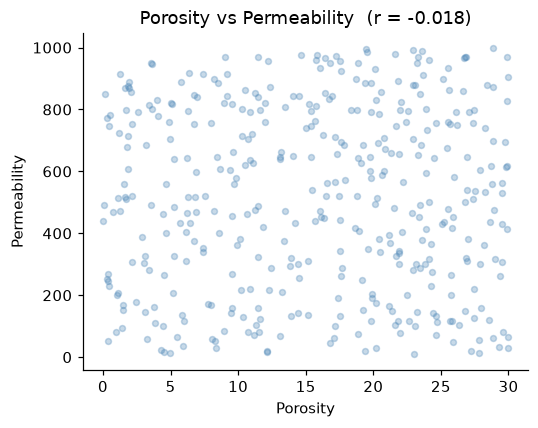

In [14]:
corr_val = train[['Porosity', 'Permeability']].corr().loc['Porosity','Permeability']
print(f"Porosity–Permeability correlation: {corr_val:.4f}")
print("(real reservoir rock typically shows positive r, often 0.5–0.8)")
print("Here it's essentially zero — further confirms the numeric features are not geologically coupled")

# quick scatter to show it visually
sample = train[['Porosity','Permeability']].dropna().sample(400, random_state=42)
fig, ax = plt.subplots(figsize=(5, 4))
ax.scatter(sample['Porosity'], sample['Permeability'], alpha=0.3, s=15, color='steelblue')
ax.set_xlabel('Porosity')
ax.set_ylabel('Permeability')
ax.set_title(f'Porosity vs Permeability  (r = {corr_val:.3f})')
plt.tight_layout()
plt.savefig('../outputs/images/porosity_perm_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

               oil_rate    n
Anticline          31.6  757
Dome               32.4  710
Fault              30.2  766
NaN (no trap)      17.3  767


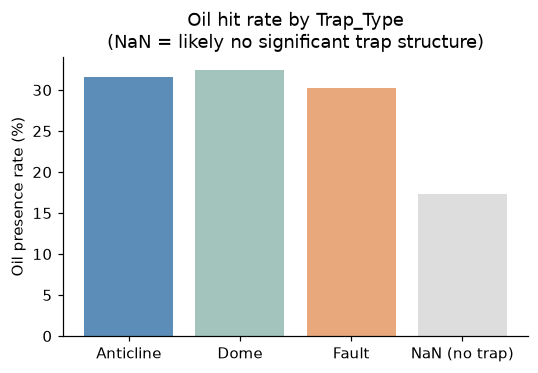

In [15]:
trap_oil = train.groupby('Trap_Type', dropna=False)['Oil_Presence'].agg(['mean','count'])
trap_oil.index = [str(i) if str(i) != 'nan' else 'NaN (no trap)' for i in trap_oil.index]
trap_oil.columns = ['oil_rate', 'n']
trap_oil['oil_rate'] = (trap_oil['oil_rate'] * 100).round(1)

print(trap_oil)

fig, ax = plt.subplots(figsize=(5, 3.5))
ax.bar(trap_oil.index, trap_oil['oil_rate'], color=['#5B8DB8','#A3C4BC','#E8A87C','#ddd'])
ax.set_ylabel('Oil presence rate (%)')
ax.set_title('Oil hit rate by Trap_Type\n(NaN = likely no significant trap structure)')
plt.tight_layout()
plt.savefig('../outputs/images/trap_type_oil_rate.png', dpi=150, bbox_inches='tight')
plt.show()

**Summary of key EDA findings:**

- 3,000 train rows / 2,000 test rows, confirmed
- Train has substantial missingness (27–42%) across all numeric features; test is nearly complete (only Trap_Type missing, ~24%)
- Target is imbalanced ~72/28 — use F1/AUC, not accuracy
- **Seismic_Score** is the strongest numeric signal (mean 0.42 no-oil vs 0.69 oil)
- **Rock_Type** shows strong categorical signal (Shale 10.3% oil rate vs 35–37% for Sandstone/Limestone)
- **Trap_Type NaN rows** have a notably lower oil rate (~17%) than named trap types (~30–32%), suggesting NaN = no trap present, not random missing data
- Porosity and Permeability are essentially flat across Rock_Types and uncorrelated with each other — not geologically realistic, but the features still carry some class signal
- No global range violations found

## 3. Part 1 — Data Science Pipeline

In [16]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

# gonna work on copies so the original dataframes stay clean
train_p1 = train.copy()
test_p1  = test.copy()

# numeric and categorical columns (excluding target)
num_cols  = ['Porosity', 'Permeability', 'Seismic_Score',
             'Proximity_to_Oil_Field', 'Estimated_Reservoir_Depth']
cat_cols  = ['Rock_Type', 'Trap_Type']

# impute numerics with median — more robust than mean given the skew we saw in EDA
num_imputer = SimpleImputer(strategy='median')
train_p1[num_cols] = num_imputer.fit_transform(train_p1[num_cols])
test_p1[num_cols]  = num_imputer.transform(test_p1[num_cols])

# impute categoricals with the most frequent value
# except Trap_Type — EDA showed NaN there likely means "no trap", so we keep it as its own category
train_p1['Rock_Type'] = train_p1['Rock_Type'].fillna(train_p1['Rock_Type'].mode()[0])
test_p1['Rock_Type']  = test_p1['Rock_Type'].fillna(train_p1['Rock_Type'].mode()[0])

train_p1['Trap_Type'] = train_p1['Trap_Type'].fillna('No_Trap')
test_p1['Trap_Type']  = test_p1['Trap_Type'].fillna('No_Trap')

# label encode the categoricals
for col in cat_cols:
    le = LabelEncoder()
    le.fit(pd.concat([train_p1[col], test_p1[col]]))  # fit on both so test labels don't break
    train_p1[col] = le.transform(train_p1[col])
    test_p1[col]  = le.transform(test_p1[col])

print("train nulls after preprocessing:", train_p1.isnull().sum().sum())
print("test nulls after preprocessing:", test_p1.isnull().sum().sum())
print("shape check — train:", train_p1.shape, "  test:", test_p1.shape)

train nulls after preprocessing: 0
test nulls after preprocessing: 0
shape check — train: (3000, 8)   test: (2000, 7)


In [17]:
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import f1_score, roc_auc_score
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

X = train_p1.drop(columns=['Oil_Presence'])
y = train_p1['Oil_Presence']
X_test = test_p1.copy()

# stratified so each fold keeps the 72/28 ratio we saw in EDA
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# base models — keeping defaults mostly, just setting seeds and suppressing verbosity
lgbm = LGBMClassifier(n_estimators=500, learning_rate=0.05, random_state=42, verbose=-1)
xgb  = XGBClassifier(n_estimators=500, learning_rate=0.05, random_state=42,
                     eval_metric='logloss', verbosity=0)
cat  = CatBoostClassifier(iterations=500, learning_rate=0.05, random_state=42, verbose=0)
rf   = RandomForestClassifier(n_estimators=300, random_state=42)

models = [('LightGBM', lgbm), ('XGBoost', xgb), ('CatBoost', cat), ('Random Forest', rf)]

print("cross-validating base models...\n")
for name, model in models:
    auc = cross_val_score(model, X, y, cv=cv, scoring='roc_auc')
    f1  = cross_val_score(model, X, y, cv=cv, scoring='f1')
    print(f"{name:15s}  AUC: {auc.mean():.4f} ± {auc.std():.4f}   F1: {f1.mean():.4f} ± {f1.std():.4f}")

cross-validating base models...

LightGBM         AUC: 0.7969 ± 0.0164   F1: 0.5820 ± 0.0405
XGBoost          AUC: 0.7947 ± 0.0121   F1: 0.5818 ± 0.0181
CatBoost         AUC: 0.8045 ± 0.0129   F1: 0.5859 ± 0.0257
Random Forest    AUC: 0.8031 ± 0.0153   F1: 0.5995 ± 0.0333
